# Bigrams Exercises Notebook
Generated from `exercises/bigrams.md`.

In [7]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu --trusted-host pypi.org --trusted-host files.pythonhosted.org

### **Part 1: Data Exploration and Preprocessing**

**Exercise 1: Loading the Dataset**  
Open the `names.txt` file, read all the names into a single string, and then split them into a Python list of strings where each element is a name.  
*   **Goal:** Verify you have approximately 32,000 names.
*   **Check:** Find and print the length of the shortest and longest names in the dataset.

In [2]:
people = open('data/names.txt','r').read().splitlines()
bands = open('data/band_names.txt','r').read().splitlines()

In [4]:
max(bands, key=len)

'Paladins of the Golden Power Fights with the Great Sword of Eternal Magic and the Great Kings Will'

<details><summary>Reference solution (hidden)</summary>

```python
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))
```

Load names as lines, then validate total count and min/max lengths to confirm preprocessing.
</details>

**Exercise 2: Identifying Bigrams**  
Iterate through the first few names and identify every "bigram" (a pair of consecutive characters).  
*   **Requirement:** Use the `zip` function to create tuples of `(character1, character2)`.
*   **Special Tokens:** To help the model understand the start and end of names, wrap each word with a special start and end token (e.g., use `<S>` and `<E>` or a simple `.`).

In [5]:
for name in bands[:3]:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

. A
A  
  B
B l
l a
a c
c k
k  
  C
C o
o l
l d
d  
  D
D i
i a
a m
m o
o n
n d
d .
. A
A  
  B
B i
i l
l l
l i
i o
o n
n  
  L
L i
i m
m b
b s
s .
. A
A  
  B
B a
a n
n d
d  
  N
N a
a m
m e
e d
d  
  J
J o
o n
n .


<details><summary>Reference solution (hidden)</summary>

```python
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)
```

Boundary tokens encode starts/ends, and `zip(chs, chs[1:])` creates consecutive bigram pairs.
</details>

### **Part 2: The Counting-Based Model**

**Exercise 3: Building a Count Dictionary**  
Create a Python dictionary where the keys are bigram tuples and the values are the number of times that bigram appears across the entire dataset.
*   **Logic:** For every word, add start/end markers and increment the count for every consecutive pair.
*   **Exploration:** Sort the dictionary by frequency to see which character pairs (like `n` at the end of a name) are most common.

In [6]:
b = {}
for name in bands:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

b

{('.', 'A'): 11551,
 ('A', ' '): 352,
 (' ', 'B'): 4384,
 ('B', 'l'): 4384,
 ('l', 'a'): 8241,
 ('a', 'c'): 6537,
 ('c', 'k'): 3656,
 ('k', ' '): 2596,
 (' ', 'C'): 5730,
 ('C', 'o'): 3542,
 ('o', 'l'): 5643,
 ('l', 'd'): 2225,
 ('d', ' '): 8552,
 (' ', 'D'): 7486,
 ('D', 'i'): 3290,
 ('i', 'a'): 7158,
 ('a', 'm'): 4429,
 ('m', 'o'): 3596,
 ('o', 'n'): 17741,
 ('n', 'd'): 7233,
 ('d', '.'): 8993,
 ('B', 'i'): 546,
 ('i', 'l'): 6635,
 ('l', 'l'): 7181,
 ('l', 'i'): 6383,
 ('i', 'o'): 8482,
 ('n', ' '): 9090,
 (' ', 'L'): 2497,
 ('L', 'i'): 1487,
 ('i', 'm'): 2853,
 ('m', 'b'): 1877,
 ('b', 's'): 834,
 ('s', '.'): 17835,
 ('B', 'a'): 1684,
 ('a', 'n'): 14356,
 (' ', 'N'): 2109,
 ('N', 'a'): 1203,
 ('m', 'e'): 4981,
 ('e', 'd'): 8130,
 (' ', 'J'): 424,
 ('J', 'o'): 264,
 ('n', '.'): 15443,
 ('a', 'l'): 14310,
 ('n', 'c'): 4072,
 ('c', 'e'): 5682,
 ('e', ' '): 15680,
 (' ', 'o'): 7565,
 ('o', 'f'): 7872,
 ('f', ' '): 7541,
 (' ', 'P'): 3529,
 ('P', 'o'): 991,
 ('o', 'w'): 3131,
 ('w', 'e')

In [7]:
sorted_b = sorted(b.items(), key=lambda kv: kv[1], reverse=True)
sorted_b[:20]

[(('e', 'r'), 25565),
 (('e', '.'), 19014),
 (('o', 'r'), 18618),
 (('s', '.'), 17835),
 (('o', 'n'), 17741),
 (('i', 'n'), 16993),
 (('e', ' '), 15680),
 (('n', '.'), 15443),
 (('.', 'S'), 15292),
 (('a', 'r'), 14882),
 (('e', 'n'), 14812),
 (('a', 't'), 14749),
 (('a', 'n'), 14356),
 (('a', 'l'), 14310),
 (('r', 'a'), 13804),
 (('t', 'h'), 13185),
 (('r', 'e'), 13080),
 (('r', '.'), 12669),
 (('e', 's'), 12539),
 (('t', 'e'), 12313)]

<details><summary>Reference solution (hidden)</summary>

```python
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

sorted_b = sorted(b.items(), key=lambda kv: kv[1], reverse=True)
sorted_b[:20]
```

Count each transition pair to build an empirical bigram model and sort to inspect dominant transitions.
</details>

**Exercise 4: Moving to Tensors**  
Instead of a dictionary, store these counts in a 2D **PyTorch tensor**.  
*   **Mapping:** Create a lookup table (dictionary) that maps every character (a–z plus your special token) to an integer index (0–26) and vice versa.
*   **Implementation:** Initialize a 27x27 tensor of zeros (using `torch.int32`) and populate it by iterating through all words and incrementing the corresponding row/column index.

In [4]:
import string
import torch

latchs = list(string.ascii_letters + string.digits) + ['.'] 
n = len(latchs)
counts = torch.zeros((n,n))
counts

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [15]:
ctoi = {}
for i in range(n):
    ctoi[latchs[i]] = i

itoc = dict(zip(ctoi.values(),ctoi.keys()))
itoc

for k in range(n):
    for j in range(n):
        counts[k,j] = b.get((itoc[k],itoc[j]),0)
counts

tensor([[5.9000e+02, 1.4850e+03, 6.5370e+03,  ..., 0.0000e+00, 1.0000e+00,
         1.0430e+04],
        [1.3120e+03, 2.0900e+02, 3.1000e+01,  ..., 1.0000e+00, 0.0000e+00,
         4.8900e+02],
        [3.7400e+03, 8.0000e+00, 3.1900e+02,  ..., 0.0000e+00, 0.0000e+00,
         1.1130e+03],
        ...,
        [1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 3.9000e+01, 2.0000e+00,
         7.2000e+01],
        [0.0000e+00, 1.0000e+00, 0.0000e+00,  ..., 5.0000e+00, 1.4000e+01,
         5.9000e+01],
        [2.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.3000e+01, 1.8000e+01,
         0.0000e+00]])

In [20]:
print(sorted_b[:10])
print(counts[ctoi['e'],ctoi['r']])
print(counts[ctoi['e'],ctoi['.']])
print(counts[ctoi['o'],ctoi['r']])

[(('e', 'r'), 25565), (('e', '.'), 19014), (('o', 'r'), 18618), (('s', '.'), 17835), (('o', 'n'), 17741), (('i', 'n'), 16993), (('e', ' '), 15680), (('n', '.'), 15443), (('.', 'S'), 15292), (('a', 'r'), 14882)]
tensor(25565.)
tensor(19014.)
tensor(18618.)


In [26]:
print((sum(sum(counts == 0))/(n*n)).data.item())
print(n*n)

0.31997984647750854
3969


In [5]:
chars = sorted(list(set(''.join(bands)))) 
ctoi = {c : i+1 for i,c in enumerate(chars)}
ctoi['.'] = 0
itoc = {i : c for c, i in ctoi.items()}

n_chars = len(chars) + 1
N = torch.zeros((n_chars,n_chars))

for band in bands:
    chs = ['.'] + list(band) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        N[ctoi[ch1], ctoi[ch2]] += 1 

In [40]:
print(sorted_b[:10])
print(N[ctoi['e'],ctoi['r']])
print(N[ctoi['e'],ctoi['.']])
print(N[ctoi['o'],ctoi['r']])

[(('e', 'r'), 25565), (('e', '.'), 19014), (('o', 'r'), 18618), (('s', '.'), 17835), (('o', 'n'), 17741), (('i', 'n'), 16993), (('e', ' '), 15680), (('n', '.'), 15443), (('.', 'S'), 15292), (('a', 'r'), 14882)]
tensor(25565.)
tensor(19014.)
tensor(18618.)


<details><summary>Reference solution (hidden)</summary>

```python
import torch
chars = sorted(list(set(''.join(words))))
s2i = {s: i + 1 for i, s in enumerate(chars)}
s2i['.'] = 0
i2s = {i: s for s, i in s2i.items()}

N = torch.zeros((27, 27), dtype=torch.int32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = s2i[ch1], s2i[ch2]
        N[ix1, ix2] += 1
```

Map characters to indices, then store transition counts in a fixed-size 27x27 matrix for vectorized processing.
</details>

**Exercise 5: Visualizing the Counts**  
Use `matplotlib` to visualize the 27x27 grid.  
*   **Task:** Overlay the bigram text and the raw count on each cell of the grid to see the statistical structure of the names.

<details><summary>Reference solution (hidden)</summary>

```python
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = i2s[i] + i2s[j]
        plt.text(j, i, chstr, va='bottom', ha='center', color='gray')
        plt.text(j, i, N[i, j].item(), va='top', ha='center', color='gray')
plt.axis('off')
```

Visualizing the matrix helps inspect frequency structure and verify indexing correctness.
</details>

### **Part 3: Sampling and Evaluation**

**Exercise 6: Generating Names by Sampling**  
Implement a loop to generate new names using the counts in your tensor.  
*   **Step A:** Convert the raw counts in a row into a probability distribution by dividing each element by the sum of the row.
*   **Step B:** Use `torch.multinomial` to sample the next character based on these probabilities.
*   **Step C:** Repeat this process, starting from the "start" token, until you sample the "end" token.

In [71]:
g = torch.Generator().manual_seed(1920)

for i in range(5):
    word = []
    ix = 0
    while True:
        p = N[ix]/N[ix].sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        word.append(itoc[ix])
        if ix == 0:
            break
    print(''.join(word))


Vapula.
Sk.
Ne Acerntoone Ed.
Marist.
Thtintehorar.


<details><summary>Reference solution (hidden)</summary>

```python
g = torch.Generator().manual_seed(2147483647)
for i in range(5):
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(i2s[ix])
        if ix == 0:
            break
    print(''.join(out))
```

Sampling row-wise probabilities generates names from the learned transition distribution.
</details>

**Exercise 7: Efficient Matrix Operations (Broadcasting)**  
To avoid recalculating probabilities in every loop, create a dedicated probability matrix `P` where every row sums to 1.  
*   **Constraint:** Use `P = (N+1).float()` (adding 1 for **model smoothing** to avoid zero-probabilities) and divide by the row sums.
*   **Implementation Detail:** Use `torch.sum(1, keepdim=True)` and ensure you understand how **broadcasting** allows a 27x27 matrix to be divided by a 27x1 vector.

In [72]:
P = (N + 1).float()
P /= P.sum(1, keepdim=True) 

In [82]:
#g = torch.Generator().manual_seed(1920)

for i in range(5):
    word = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        word.append(itoc[ix])
        if ix == 0:
            break
    print(''.join(word))

Kr.
Red Pll.
Fonice.
Degengr Wonar.
Kristorozid Sac Ocrapanis.


<details><summary>Reference solution (hidden)</summary>

```python
P = (N + 1).float()
P /= P.sum(1, keepdim=True)
```

Additive smoothing avoids zeros and broadcasting normalizes each row into a probability distribution.
</details>

**Exercise 8: Calculating the Loss (Negative Log Likelihood)**  
Evaluate the quality of your model using a single numerical value.  
*   **Concept:** For every bigram in your dataset, find the probability the model assigned to it.
*   **Calculation:** Calculate the **log likelihood** by summing the logs of these probabilities.
*   **Result:** The loss is the **negative average log likelihood**. A lower value means a better model.

In [ ]:
log_likelihood = 0.0
n = 0

for band in bands:
# for band in ['Talitha']
    chs = ['.'] + list(band) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = ctoi[ch1], ctoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f'{ch1}{ch2}:{prob:.4f}, {logprob:.4f}')

nll = -log_likelihood
print(f'nll = {nll/n}')

n_chars = P.shape[0]

nll = 2.6108498573303223


<details><summary>Reference solution (hidden)</summary>

```python
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = s2i[ch1], s2i[ch2]
        prob = P[ix1, ix2]
        log_likelihood += torch.log(prob)
        n += 1
nll = -log_likelihood
print(f'{nll / n:.4f}')
```

Average NLL summarizes model quality: lower loss means higher assigned probability to observed data.
</details>

### **Part 4: The Neural Network Approach**

**Exercise 9: Preparing the Training Set**  
Re-cast the bigram problem into a supervised learning task.
*   **Inputs (X):** A tensor of the first character's integer index for every bigram.
*   **Labels (Y):** A tensor of the second character's integer index for every bigram.
*   **Check:** If training on just the name "emma", verify you have 5 input-label pairs.

In [104]:
# Create the training set
xs, ys = [], []

for band in bands[:1]:
# for band in ['Talitha']
    chs = ['.'] + list(band) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = ctoi[ch1], ctoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

<details><summary>Reference solution (hidden)</summary>

```python
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(s2i[ch1])
        ys.append(s2i[ch2])
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
```

Convert text transitions into supervised input/target tensors for classification training.
</details>

**Exercise 10: One-Hot Encoding**  
Because you cannot feed raw integers into a neural network, convert your input tensor `X` into a **one-hot encoded** tensor.
*   **Implementation:** Use `torch.nn.functional.one_hot` and cast the result to `float32`.

In [8]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=n_chars)
xenc.shape

torch.Size([1698882, 64])

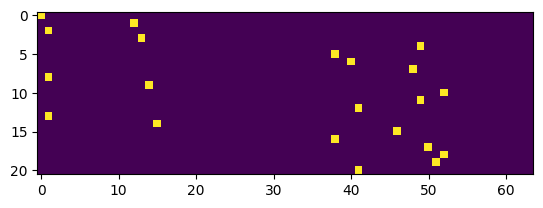

In [109]:
plt.imshow(xenc)

In [110]:
xenc.dtype

torch.int64

In [111]:
xenc = F.one_hot(xs, num_classes=P.shape[0]).float()

<details><summary>Reference solution (hidden)</summary>

```python
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
```

One-hot encoding turns categorical indices into numeric vectors usable by a linear layer.
</details>

**Exercise 11: The Forward Pass (Linear Layer & Softmax)**  
Build the simplest possible neural network: a single linear layer.
*   **Weights:** Initialize a 27x27 weight matrix `W` with random values.
*   **Matrix Multiplication:** Multiply your one-hot inputs by `W` to get "logits".
*   **Softmax:** Exponentiate the logits and normalize them to produce a probability distribution for every input example.

In [ ]:
W = torch.randn((n_chars,1))

# (21, 64) * (64, 1) -> (21, 1)
xenc @ W 

tensor([[ 0.6483],
        [ 0.5693],
        [ 1.2927],
        [-0.6925],
        [-0.8133],
        [ 1.7213],
        [-1.5275],
        [ 1.5144],
        [ 1.2927],
        [-0.8809],
        [-1.2912],
        [-0.8133],
        [-0.5745],
        [ 1.2927],
        [ 0.4364],
        [ 0.8406],
        [ 1.7213],
        [-0.5274],
        [-1.2912],
        [-0.0164],
        [-0.5745]])

In [ ]:
W = torch.randn((n_chars,n_chars))

# (21, 64) * (64, 64) -> (21, 64)
xenc @ W 

tensor([[-0.3474, -0.5130, -0.8166,  ...,  0.2164, -1.4565,  1.3157],
        [-0.9916, -0.8164,  0.0697,  ..., -1.1589, -0.4038, -0.9739],
        [-0.4825, -0.0080,  0.7755,  ..., -0.3182,  1.0839,  0.1546],
        ...,
        [-0.7247, -0.5895, -1.0509,  ...,  1.1643,  0.3406, -2.4735],
        [ 0.7848, -0.6976,  2.5726,  ...,  0.3170, -0.6532, -0.2828],
        [ 0.1021, -1.5269,  1.4220,  ..., -0.0472, -1.2359,  0.7010]])

In [ ]:
(xenc @ W)[3,13]
# firing rate of 13th neuron for the 3rd input

tensor(1.4574)

In [121]:
(xenc[3,] * W[:,13]).sum()

tensor(1.4574)

In [12]:
logits = (xenc @ W) #log-counts
counts = logits.exp() #equivalent to N
probs = counts / counts.sum(1, keepdims = True) #soft-max
nll = -torch.log(probs).mean().item()
print(nll)


4.640380859375


<details><summary>Reference solution (hidden)</summary>

```python
W = torch.randn((27, 27), requires_grad=True)
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
```

A single linear layer with softmax-style normalization yields next-character probabilities.
</details>

**Exercise 12: Optimization (The Training Loop)**  
Implement the gradient descent loop to tune the weights `W`.
*   **Zero Grad:** Set gradients to `None`.
*   **Backward Pass:** Call `.backward()` on your negative log likelihood loss to compute the gradients of the weights.
*   **Update:** Nudge the weights in the opposite direction of the gradient using a learning rate (e.g., `0.1` or `50`).
*   **Goal:** Watch the loss decrease over several iterations until it matches the loss from the counting-based model.

In [86]:
# Training set
xs, ys = [], []

for band in bands:
    chs = ['.'] + list(band) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = ctoi[ch1], ctoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(num)

# Initialization
g = torch.Generator().manual_seed(5390438945)
W = torch.randn((n_chars,n_chars), requires_grad=True, generator=g)

1698882


In [87]:
xenc = F.one_hot(xs, num_classes=n_chars).float()

In [88]:
xenc.shape

torch.Size([1698882, 64])

In [89]:
W.shape

torch.Size([64, 64])

In [90]:
logits = (xenc @ W)
logits.shape

torch.Size([1698882, 64])

In [92]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdims = True)
probs.shape

torch.Size([1698882, 64])

In [93]:
xs.shape

torch.Size([1698882])

In [91]:
for k in range(500):

    # forward pass
    logits = (xenc @ W) #log-counts
    counts = logits.exp() #equivalent to N
    probs = counts / counts.sum(1, keepdims = True) #soft-max
    loss = -probs[torch.arange(xs.shape[0]), ys].log().mean() + 0.1*(W**2).mean()
    print(loss.item())

    # backward pass
    W.grad = None
    loss.backward()

    # update
    W.data += -100 * W.grad

2.7915592193603516
2.7914843559265137
2.7914106845855713
2.7913382053375244
2.791266441345215
2.7911951541900635
2.7911252975463867
2.7910561561584473
2.7909882068634033
2.7909202575683594
2.790853977203369
2.790787696838379
2.790722608566284
2.790658712387085
2.790595293045044
2.7905328273773193
2.790470838546753
2.790410041809082
2.7903494834899902
2.790290117263794
2.7902309894561768
2.790173053741455
2.7901155948638916
2.7900590896606445
2.7900028228759766
2.789947509765625
2.7898926734924316
2.7898387908935547
2.789785623550415
2.7897326946258545
2.7896804809570312
2.7896292209625244
2.789578676223755
2.7895283699035645
2.7894787788391113
2.7894299030303955
2.789381742477417
2.7893338203430176
2.7892866134643555
2.7892401218414307
2.789194345474243
2.7891485691070557
2.7891035079956055
2.7890591621398926
2.789015293121338
2.7889716625213623
2.7889292240142822
2.788886785507202
2.7888450622558594
2.7888033390045166
2.7887625694274902
2.788722038269043
2.788682460784912
2.7886431217

In [99]:
#g = torch.Generator().manual_seed(83689479)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    x = F.one_hot(torch.tensor([ix]), num_classes=64).float()
    logcounts = x @ W # predict log-counts
    cnts = logcounts.exp() # counts, equivalent to N
    p = cnts / cnts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itoc[ix])
    if ix == 0:
      break
  print(''.join(out))

Met CRotowirheay Wiatarist.
Ma.
An.
Dioph.
HosblintSaleheNInd.


<details><summary>Reference solution (hidden)</summary>

```python
for k in range(100):
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    loss = -probs[torch.arange(num), ys].log().mean()
    W.grad = None
    loss.backward()
    W.data += -50 * W.grad
```

Train by repeating forward pass, NLL loss, backpropagation, and gradient-descent updates.
</details>

### **Part 5: Advanced Challenges (Trigram Exercises)**

1.  **Trigram Model:** Train a model that takes *two* characters as input to predict the 3rd one. Evaluate if the loss improves over the bigram version.

In [157]:
bands = open('data/band_names.txt','r').read().splitlines()
chars = sorted(set(list(''.join(bands)))) + ['.']
n_chars = len(chars) 
print(n_chars)

64


In [158]:
ctoi = {c : i+1 for i,c in enumerate(chars)}
ctoi['.'] = 0
itoc = {i : c for c, i in ctoi.items()}

In [165]:
import itertools
combos = [''.join(pair) for pair in itertools.product(chars, repeat=2)]

# Create a dictionary with sequential numbers
btoi = {combo: i for i, combo in enumerate(combos)}
itob = {i : b for b, i in btoi.items()}

In [166]:
import torch

# Training set
xs, ys = [], []

for band in bands:
    chs = ['.','.'] + list(band) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1, ix2, ix3 = ctoi[ch1], ctoi[ch2], ctoi[ch3]
        b = f'{itoc[ix1]}{itoc[ix2]}'
        #print(f'{itob[fi]} ---> {itoc[ix3]}')
        xs.append(btoi[b])
        ys.append(ix3)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [169]:
#import torch.nn.functional as F
#xenc = F.one_hot(xs, num_classes=n_chars**2).float()
g = torch.Generator().manual_seed(5392138945)
W = torch.randn((n_chars**2,n_chars), requires_grad=True, generator=g)

In [170]:
counts = W.exp()
probs = counts / counts.sum(1, keepdims = True)
loss = -probs[xs,ys].log().mean()
loss.item()

4.614985466003418

In [181]:
for k in range(10000):

    # forward pass
    counts = W.exp()
    probs = counts / counts.sum(1, keepdims = True)
    loss = -probs[xs,ys].log().mean() + 0.2*(W**2).mean()
    print(loss.item())

    # backward pass
    W.grad = None
    loss.backward()

    # update
    W.data += -200 * W.grad

2.386988639831543
2.386988401412964
2.386988401412964
2.3869881629943848
2.3869879245758057
2.3869876861572266
2.3869872093200684
2.3869872093200684
2.3869869709014893
2.3869869709014893
2.3869869709014893
2.386986494064331
2.386986017227173
2.386986017227173
2.3869857788085938
2.3869855403900146
2.3869853019714355
2.3869853019714355
2.3869850635528564
2.3869850635528564
2.3869845867156982
2.386984348297119
2.386984348297119
2.38698410987854
2.386983871459961
2.386983633041382
2.3869833946228027
2.3869833946228027
2.3869831562042236
2.3869826793670654
2.3869824409484863
2.3869826793670654
2.3869824409484863
2.3869822025299072
2.386981725692749
2.386981725692749
2.386981725692749
2.38698148727417
2.3869810104370117
2.3869807720184326
2.3869807720184326
2.3869805335998535
2.3869802951812744
2.3869800567626953
2.386979818344116
2.386979818344116
2.386979818344116
2.386979579925537
2.386979103088379
2.3869788646698
2.3869788646698
2.3869786262512207
2.3869786262512207
2.3869781494140625
2.

KeyboardInterrupt: 

In [193]:
#g = torch.Generator().manual_seed(83689479)

for i in range(10):

  out = ['.']
  ix = btoi['..']
  while True:
    
    lgcs = W[ix] # predict log-counts
    cnts = lgcs.exp() # counts, equivalent to N
    p = cnts / cnts.sum() # probabilities for next character
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itoc[ix])
    
    ctx = ''.join(out[-2:])
    ix = btoi[ctx]
    
    if out[-1] == '.':
      break
  print(''.join(out))

.Brum8mKPUnion.
.In Blitu.
.Ste.
.Hathwardion Vord.
.Intra.
.Sersus.
.Stor Slace.
.SwartosiOld Testor.
.Crossory.
.Fatomp8Abark Rem.


<details><summary>Reference solution (hidden)</summary>

```python
N3 = torch.zeros((27 * 27, 27), dtype=torch.int32)
for w in words:
    chs = ['.'] + ['.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix12 = s2i[ch1] * 27 + s2i[ch2]
        N3[ix12, s2i[ch3]] += 1
P3 = (N3 + 1).float()
P3 /= P3.sum(1, keepdim=True)
```

Use two-character context by flattening `(c1, c2)` into one row index. More context often lowers loss.
</details>

2.  **Dataset Splitting:** Split your data into 80% training, 10% development, and 10% test sets. Train only on the training set and evaluate on the others.

<details><summary>Reference solution (hidden)</summary>

```python
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
words_tr = words[:n1]
words_dev = words[n1:n2]
words_te = words[n2:]
```

Split data so tuning decisions use dev and final reporting uses untouched test data.
</details>

3.  **Smoothing Tuning:** Use the development set to find the best smoothing/regularization strength for your trigram model.

<details><summary>Reference solution (hidden)</summary>

```python
alphas = [1.0, 0.1, 0.01]
best_alpha, best_dev_loss = None, float('inf')
for alpha in alphas:
    P3 = (N3 + alpha).float()
    P3 /= P3.sum(1, keepdim=True)
    # compute dev loss and keep best alpha

# Neural net regularization idea:
# loss += 0.01 * (W**2).mean()
```

Choose smoothing/regularization via dev loss; do not tune on test.
</details>

4.  **Optimization Trick:** Remove the use of `F.one_hot` and instead use the integer indices to directly index into the rows of `W`.

<details><summary>Reference solution (hidden)</summary>

```python
# Instead of xenc @ W, use:
logits = W[xs]
```

Direct indexing is equivalent to one-hot multiplication and avoids building a sparse one-hot tensor.
</details>

5.  **Efficient Loss:** Replace your manual negative log likelihood calculation with `F.cross_entropy`.

<details><summary>Reference solution (hidden)</summary>

```python
import torch.nn.functional as F
logits = W[xs]
loss = F.cross_entropy(logits, ys)
```

`F.cross_entropy` is stable and combines log-softmax with NLL in one operation.
</details>